<a href="https://colab.research.google.com/github/NandaKishore-04/Employee-Productivity-Analysis/blob/main/Employee_Productivity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Load Dataset

df = pd.read_csv("/content/Employees Final Dataset.csv")

# Display first 5 rows
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (17417, 13)


In [ ]:
print(df.columns)

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met_more_than_80', 'awards_won',
       'avg_training_score'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [ ]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17417.000000,17417.000000,17417.000000,16054.000000,17417.000000,17417.000000,17417.000000,17417.000000
mean,39083.491129,1.250732,34.807774,3.345459,5.801860,0.358845,0.023368,63.176322
std,22707.024087,0.595692,7.694046,1.265386,4.175533,0.479675,0.151074,13.418179
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19281.000000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39122.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

education                771
previous_year_rating    1363
dtype: int64


In [ ]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 2


In [ ]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

# Check dataset shape after removing duplicates
print("Dataset Shape:", df.shape)

# Verify duplicates again
print("Duplicate Records:", df.duplicated().sum())

Dataset Shape: (17415, 13)
Duplicate Records: 0


In [ ]:
df.sample(10)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
1370,69119,Operations,region_26,Bachelors,f,other,1,34,5.0,5,1,0,59
3580,37369,Technology,region_6,Bachelors,m,other,1,28,3.0,5,0,0,80
11098,8895,Technology,region_1,Masters & above,m,other,1,35,1.0,2,0,0,79
4659,53962,Sales & Marketing,region_9,Bachelors,m,other,1,29,3.0,3,0,0,42
8022,14913,Finance,region_22,Masters & above,m,other,1,36,4.0,5,0,0,62
14069,24336,Analytics,region_22,Masters & above,m,other,1,43,5.0,15,1,0,85
6962,11670,Finance,region_2,Bachelors,m,sourcing,1,30,3.0,4,0,0,62
16354,12294,Procurement,region_2,NaN,m,sourcing,3,35,3.0,5,1,0,64
16170,39415,Operations,region_22,Bachelors,m,sourcing,2,32,3.0,2,0,0,59
3066,11187,Operations,region_28,Bachelors,m,sourcing,1,31,4.0,7,0,0,58


In [ ]:
df.dtypes

,0
employee_id,int64
department,object
region,object
education,object
gender,object
recruitment_channel,object
no_of_trainings,int64
age,int64
previous_year_rating,float64
length_of_service,int64


In [ ]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 employee_id
[ 8724 74430 72255 ... 73858 64573 49584]

 department
['Technology' 'HR' 'Sales & Marketing' 'Procurement' 'Finance' 'Analytics'
 'Operations' 'Legal' 'R&D']

 region
['region_26' 'region_4' 'region_13' 'region_2' 'region_29' 'region_7'
 'region_22' 'region_16' 'region_17' 'region_24' 'region_11' 'region_27'
 'region_9' 'region_20' 'region_34' 'region_23' 'region_8' 'region_14'
 'region_31' 'region_19' 'region_5' 'region_28' 'region_15' 'region_3'
 'region_25' 'region_12' 'region_21' 'region_30' 'region_10' 'region_33'
 'region_32' 'region_6' 'region_1' 'region_18']

 education
['Bachelors' 'Masters & above' nan 'Below Secondary']

 gender
['m' 'f']

 recruitment_channel
['sourcing' 'other' 'referred']

 no_of_trainings
[1 3 2 4 5 7 6 8 9]

 age
[24 31 30 36 33 51 29 40 34 37 26 49 27 25 41 52 43 35 42 57 46 21 32 28
 38 23 58 54 44 48 45 39 59 53 56 47 22 20 50 55 60]

 previous_year_rating
[nan  3.  1.  2.  4.  5.]

 length_of_service
[ 1  5  4  9  7  2  3 11 12 10  6 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17415 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17415 non-null  int64  
 1   department             17415 non-null  object 
 2   region                 17415 non-null  object 
 3   education              16644 non-null  object 
 4   gender                 17415 non-null  object 
 5   recruitment_channel    17415 non-null  object 
 6   no_of_trainings        17415 non-null  int64  
 7   age                    17415 non-null  int64  
 8   previous_year_rating   16052 non-null  float64
 9   length_of_service      17415 non-null  int64  
 10  KPIs_met_more_than_80  17415 non-null  int64  
 11  awards_won             17415 non-null  int64  
 12  avg_training_score     17415 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.9+ MB


In [ ]:
df.to_csv("Cleaned Employee Productivity Dataset.csv", index=False)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!


In [ ]:
# Create Age Groups

df['Age_Group'] = pd.cut(
    df['age'],
    bins=[20, 30, 40, 50, 60],
    labels=['21-30', '31-40', '41-50', '51-60']
)

df[['age', 'Age_Group']].head()

,age,Age_Group
0,24,21-30
1,31,31-40
2,31,31-40
3,31,31-40
4,30,21-30


In [ ]:
# Experience Level

df['Experience_Level'] = pd.cut(
    df['length_of_service'],
    bins=[0, 5, 10, 20, 40],
    labels=['Beginner', 'Intermediate', 'Experienced', 'Expert']
)

df[['length_of_service', 'Experience_Level']].head()

,length_of_service,Experience_Level
0,1,Beginner
1,5,Beginner
2,4,Beginner
3,9,Intermediate
4,7,Intermediate


In [ ]:
# Training Category

df['Training_Category'] = pd.cut(
    df['avg_training_score'],
    bins=[0, 50, 70, 85, 100],
    labels=['Low', 'Average', 'Good', 'Excellent']
)

df[['avg_training_score', 'Training_Category']].head()

,avg_training_score,Training_Category
0,77,Good
1,51,Average
2,47,Low
3,65,Average
4,61,Average


In [ ]:
# KPI Status

df['KPI_Status'] = df['KPIs_met_more_than_80'].map({
    1: 'Achieved',
    0: 'Not Achieved'
})

df[['KPIs_met_more_than_80', 'KPI_Status']].head()

,KPIs_met_more_than_80,KPI_Status
0,1,Achieved
1,0,Not Achieved
2,0,Not Achieved
3,0,Not Achieved
4,0,Not Achieved


In [ ]:
# Award Status

df['Award_Status'] = df['awards_won'].map({
    1: 'Award Won',
    0: 'No Award'
})

df[['awards_won', 'Award_Status']].head()

,awards_won,Award_Status
0,0,No Award
1,0,No Award
2,0,No Award
3,0,No Award
4,0,No Award


In [ ]:
# Performance Rating Category

df['Performance_Category'] = pd.cut(
    df['previous_year_rating'],
    bins=[0, 2, 3, 4, 5],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)

df[['previous_year_rating', 'Performance_Category']].head()

,previous_year_rating,Performance_Category
0,NaN,NaN
1,3.0,Average
2,1.0,Poor
3,2.0,Poor
4,4.0,Good


In [ ]:
# Check Newly Created Columns

df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met_more_than_80', 'awards_won',
       'avg_training_score', 'Age_Group', 'Experience_Level',
       'Training_Category', 'KPI_Status', 'Award_Status',
       'Performance_Category'],
      dtype='object')

In [ ]:
df.to_csv("Employee Productivity Feature Engineered.csv", index=False)

print("Feature Engineered Dataset Saved Successfully!")

Feature Engineered Dataset Saved Successfully!


/tmp/ipykernel_2694/2828741171.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


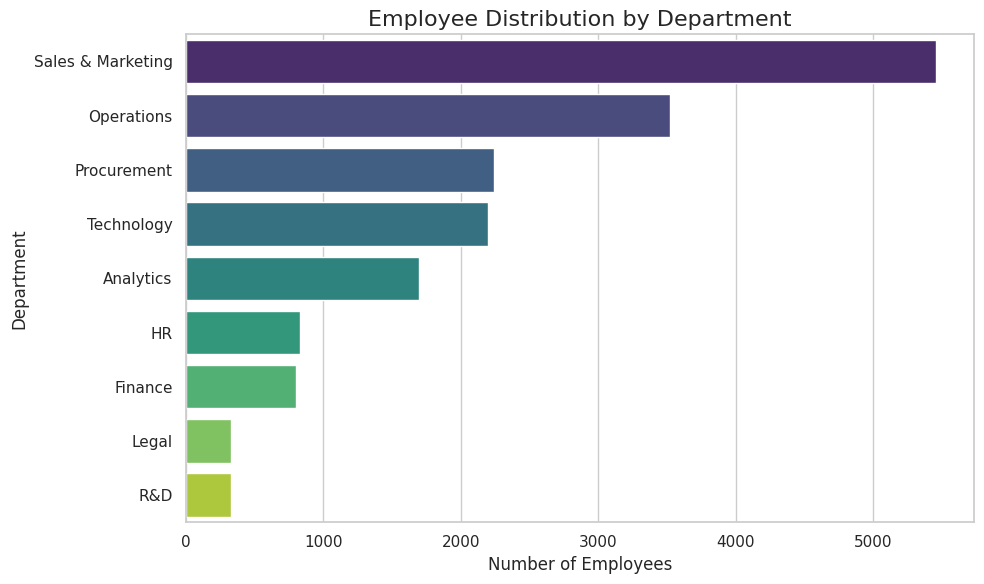

In [ ]:
# Chart 1: Employee Distribution by Department

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='department',
    order=df['department'].value_counts().index,
    palette='viridis'
)

plt.title("Employee Distribution by Department", fontsize=16)
plt.xlabel("Number of Employees")
plt.ylabel("Department")

plt.tight_layout()

plt.savefig("Employee Distribution by Department.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/2907336623.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


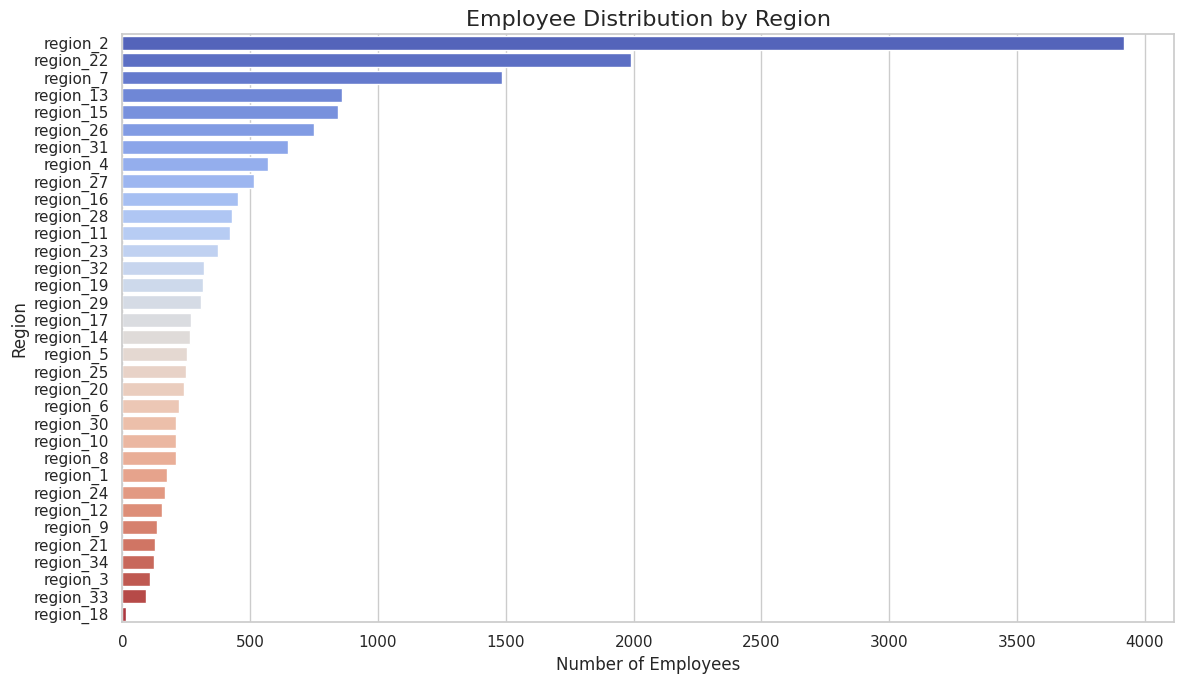

In [ ]:
# Chart 2: Employee Distribution by Region

plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y='region',
    order=df['region'].value_counts().index,
    palette='coolwarm'
)

plt.title("Employee Distribution by Region", fontsize=16)
plt.xlabel("Number of Employees")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig("Employee Distribution by Region.png", dpi=300)

plt.show()

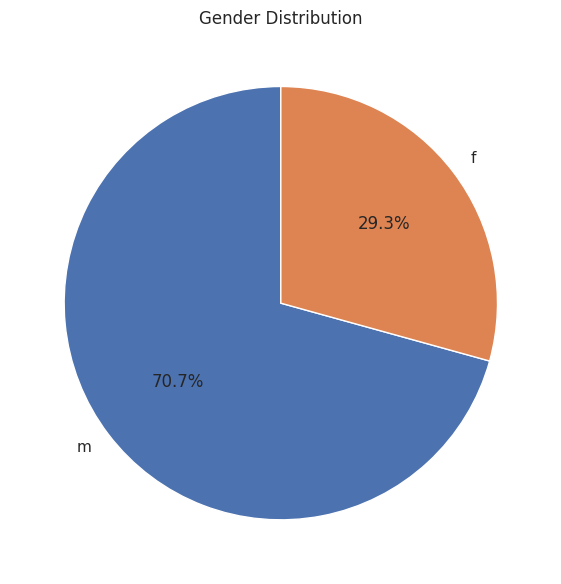

In [ ]:
# Chart 3: Gender Distribution

plt.figure(figsize=(6,6))

df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.tight_layout()

plt.savefig("Gender Distribution.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/826472141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


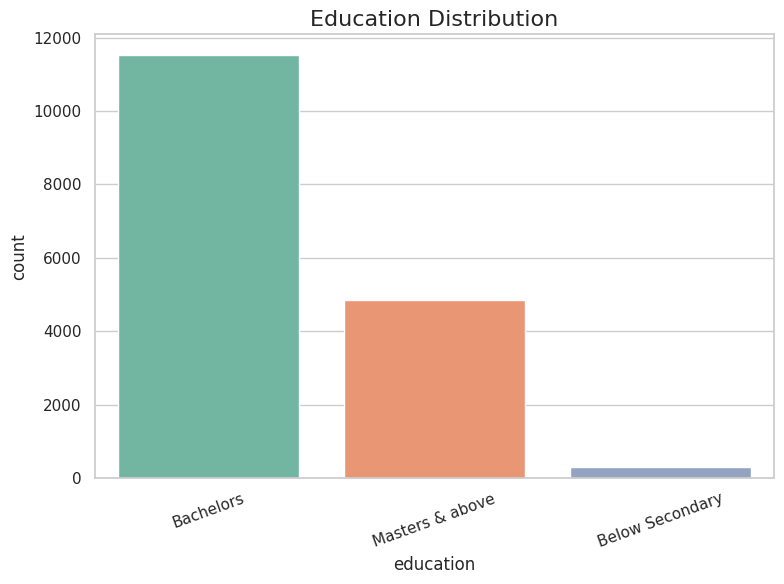

In [ ]:
# Chart 4: Education Distribution

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='education',
    palette='Set2'
)

plt.title("Education Distribution", fontsize=16)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("Education Distribution.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/2694211174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


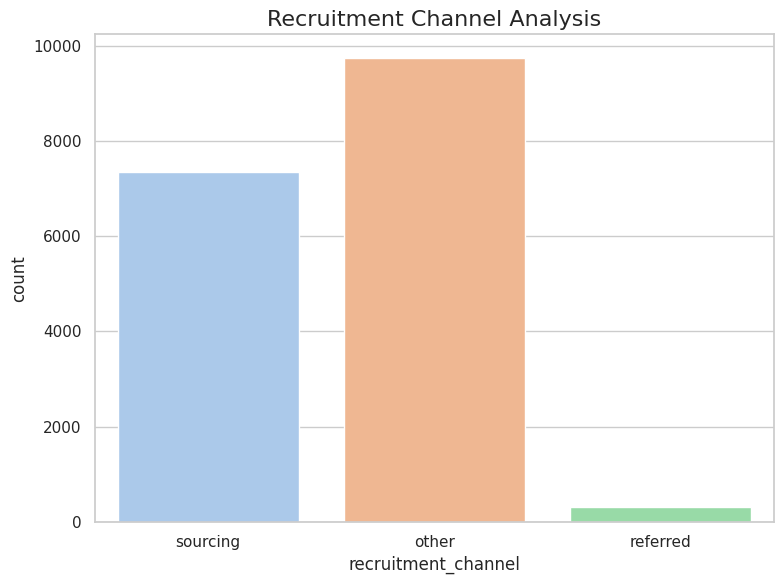

In [ ]:
# Chart 5: Recruitment Channel Analysis

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='recruitment_channel',
    palette='pastel'
)

plt.title("Recruitment Channel Analysis", fontsize=16)

plt.tight_layout()

plt.savefig("Recruitment Channel Analysis.png", dpi=300)

plt.show()

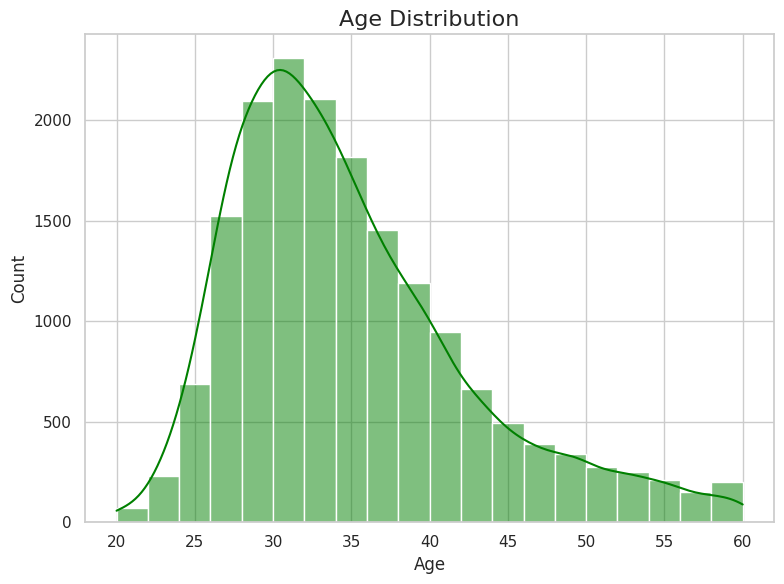

In [ ]:
# Chart 6: Age Distribution

plt.figure(figsize=(8,6))

sns.histplot(
    df['age'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("Age Distribution", fontsize=16)

plt.xlabel("Age")

plt.tight_layout()

plt.savefig("Age Distribution.png", dpi=300)

plt.show()

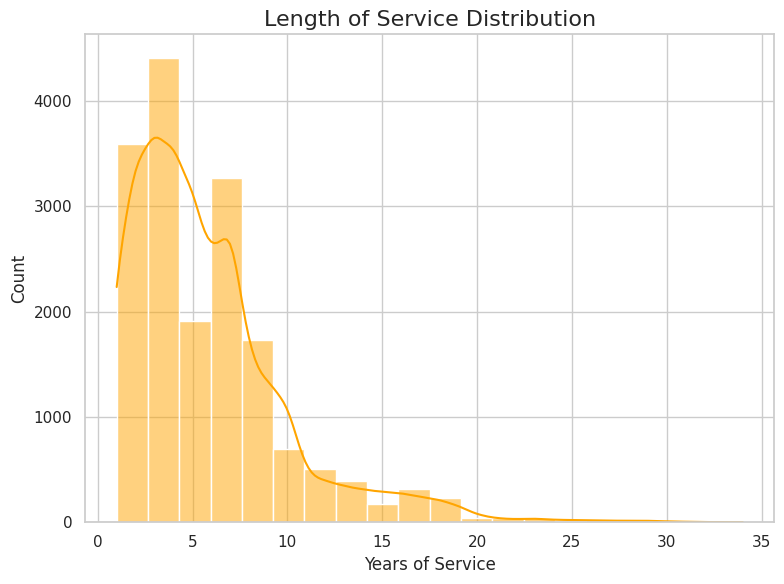

In [ ]:
# Chart 7: Length of Service Distribution

plt.figure(figsize=(8,6))

sns.histplot(
    df['length_of_service'],
    bins=20,
    kde=True,
    color='orange'
)

plt.title("Length of Service Distribution", fontsize=16)

plt.xlabel("Years of Service")

plt.tight_layout()

plt.savefig("Length of Service Distribution.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/3004691577.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


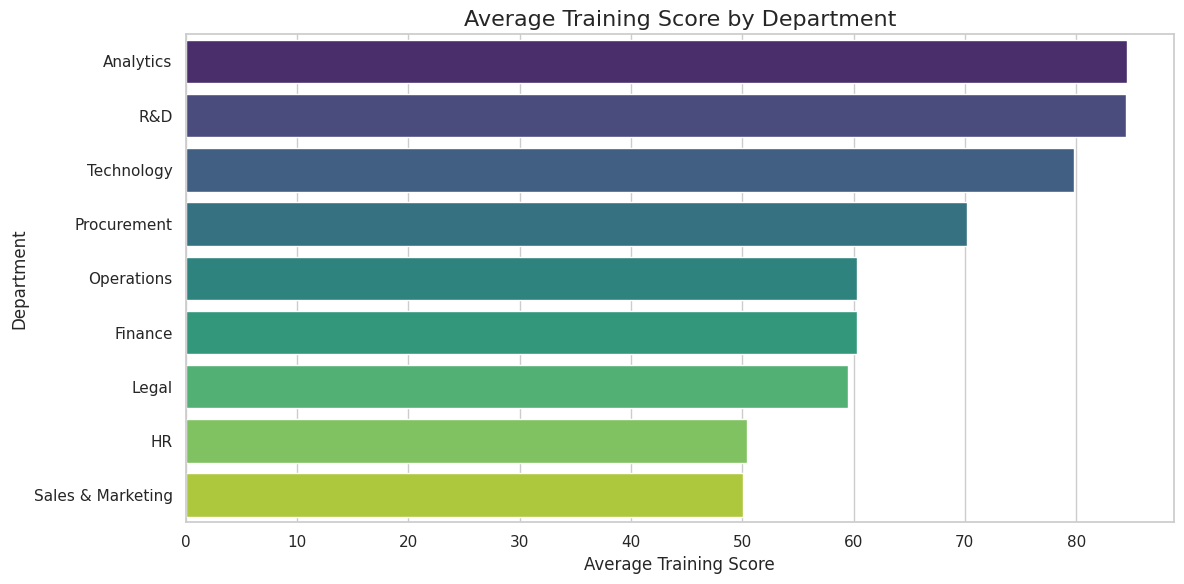

In [ ]:
# Chart 8: Average Training Score by Department

plt.figure(figsize=(12,6))

department_score = df.groupby('department')['avg_training_score'].mean().sort_values(ascending=False)

sns.barplot(
    x=department_score.values,
    y=department_score.index,
    palette='viridis'
)

plt.title("Average Training Score by Department", fontsize=16)
plt.xlabel("Average Training Score")
plt.ylabel("Department")

plt.tight_layout()

plt.savefig("Average Training Score by Department.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/2352617098.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


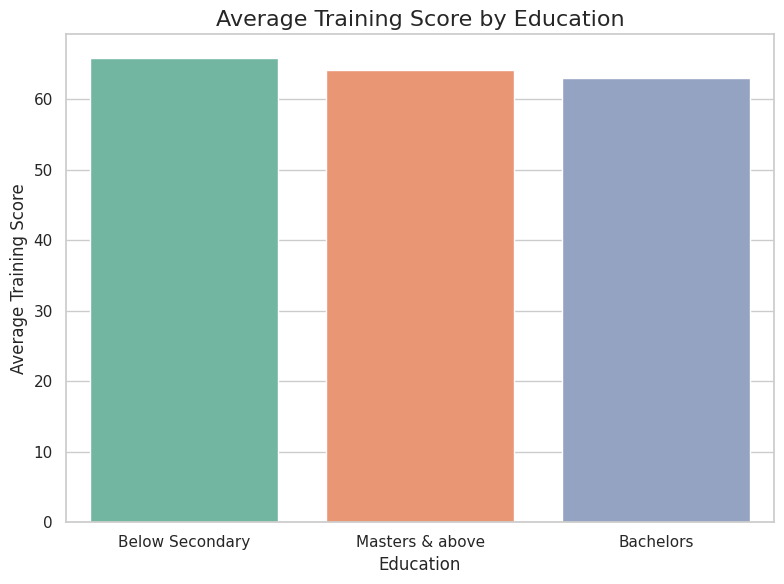

In [ ]:
# Chart 9: Average Training Score by Education

plt.figure(figsize=(8,6))

education_score = df.groupby('education')['avg_training_score'].mean().sort_values(ascending=False)

sns.barplot(
    x=education_score.index,
    y=education_score.values,
    palette='Set2'
)

plt.title("Average Training Score by Education", fontsize=16)
plt.xlabel("Education")
plt.ylabel("Average Training Score")

plt.tight_layout()

plt.savefig("Average Training Score by Education.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/230479525.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


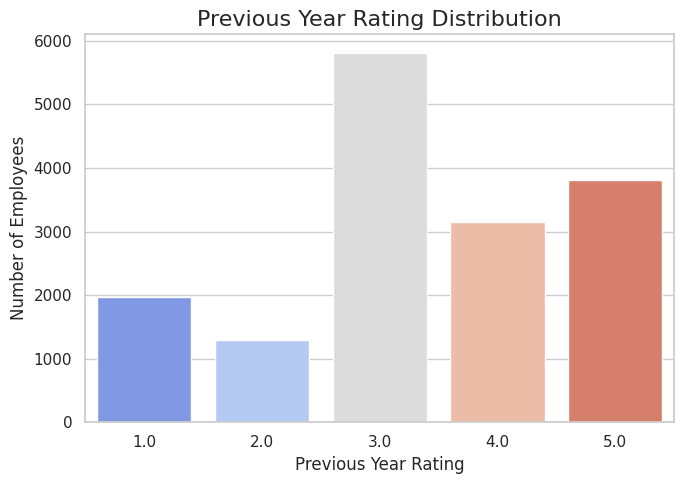

In [ ]:
# Chart 10: Previous Year Rating Distribution

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='previous_year_rating',
    palette='coolwarm'
)

plt.title("Previous Year Rating Distribution", fontsize=16)
plt.xlabel("Previous Year Rating")
plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig("Previous Year Rating Distribution.png", dpi=300)

plt.show()

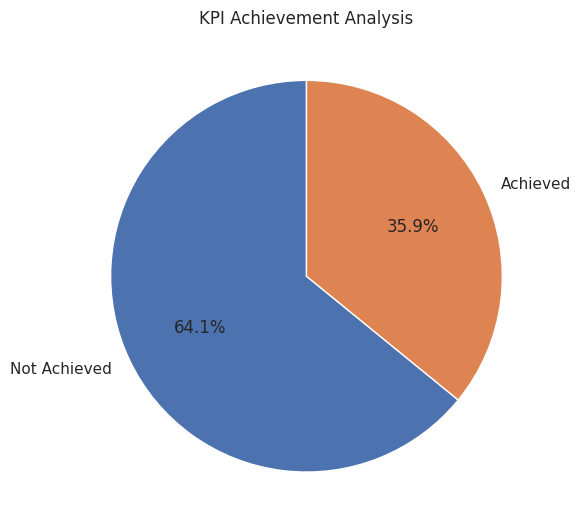

In [ ]:
# Chart 11: KPI Achievement Analysis

plt.figure(figsize=(6,6))

df['KPI_Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("KPI Achievement Analysis")

plt.ylabel("")

plt.tight_layout()

plt.savefig("KPI Achievement Analysis.png", dpi=300)

plt.show()

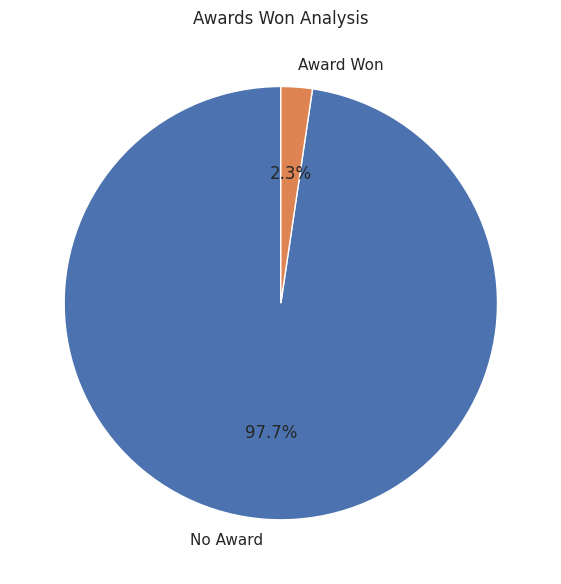

In [ ]:
# Chart 12: Awards Won Analysis

plt.figure(figsize=(6,6))

df['Award_Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Awards Won Analysis")

plt.ylabel("")

plt.tight_layout()

plt.savefig("Awards Won Analysis.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/165635642.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


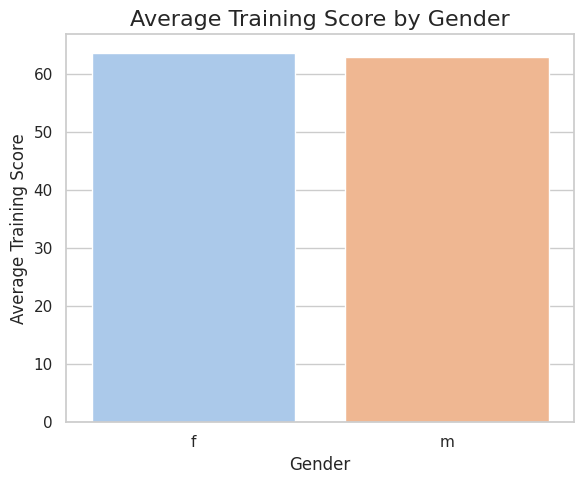

In [ ]:
# Chart 13: Average Training Score by Gender

plt.figure(figsize=(6,5))

gender_score = df.groupby('gender')['avg_training_score'].mean()

sns.barplot(
    x=gender_score.index,
    y=gender_score.values,
    palette='pastel'
)

plt.title("Average Training Score by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Average Training Score")

plt.tight_layout()

plt.savefig("Average Training Score by Gender.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/1098701203.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_score = df.groupby('Age_Group')['avg_training_score'].mean()
/tmp/ipykernel_2694/1098701203.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


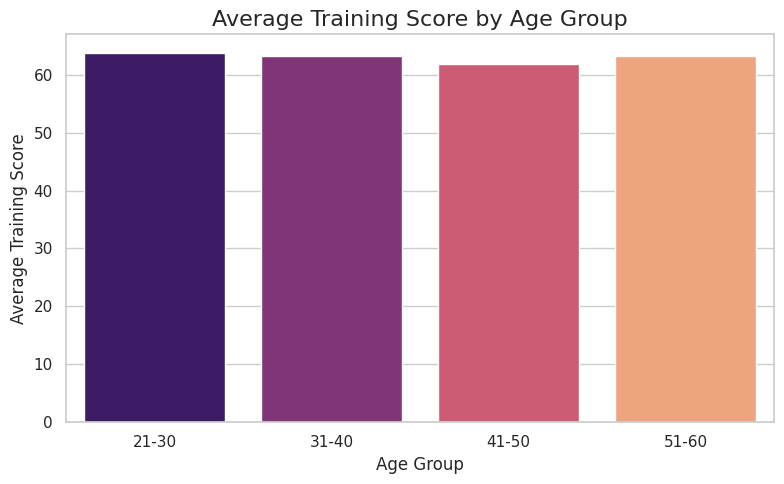

In [ ]:
# Chart 14: Average Training Score by Age Group

plt.figure(figsize=(8,5))

age_score = df.groupby('Age_Group')['avg_training_score'].mean()

sns.barplot(
    x=age_score.index,
    y=age_score.values,
    palette='magma'
)

plt.title("Average Training Score by Age Group", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Average Training Score")

plt.tight_layout()

plt.savefig("Average Training Score by Age Group.png", dpi=300)

plt.show()

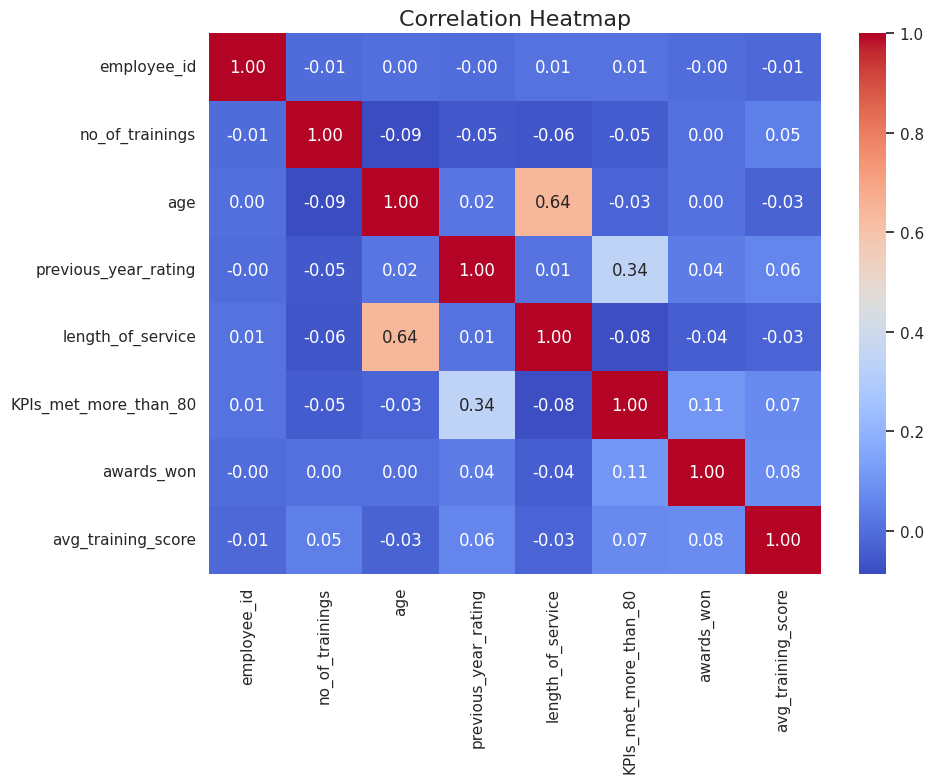

In [ ]:
# Chart 15: Correlation Heatmap

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.tight_layout()

plt.savefig("Correlation Heatmap.png", dpi=300)

plt.show()

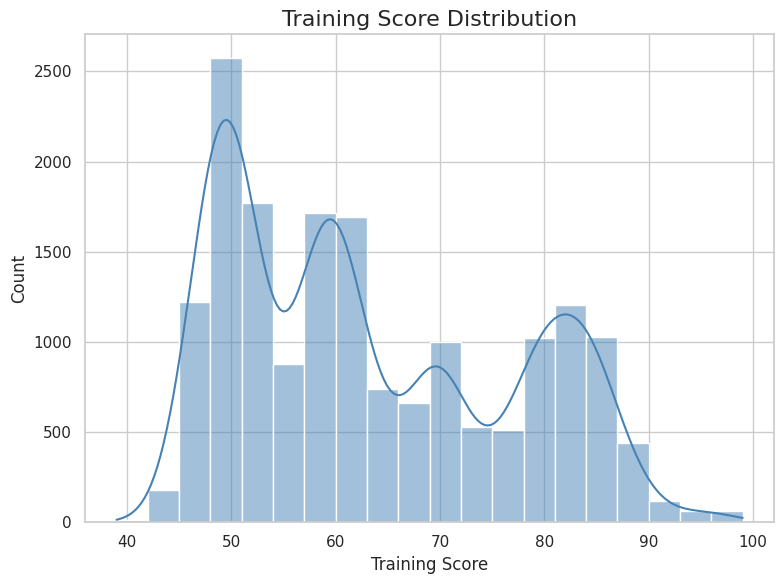

In [ ]:
# Chart 16: Training Score Distribution

plt.figure(figsize=(8,6))

sns.histplot(
    df['avg_training_score'],
    bins=20,
    kde=True,
    color='steelblue'
)

plt.title("Training Score Distribution", fontsize=16)

plt.xlabel("Training Score")

plt.tight_layout()

plt.savefig("Training Score Distribution.png", dpi=300)

plt.show()

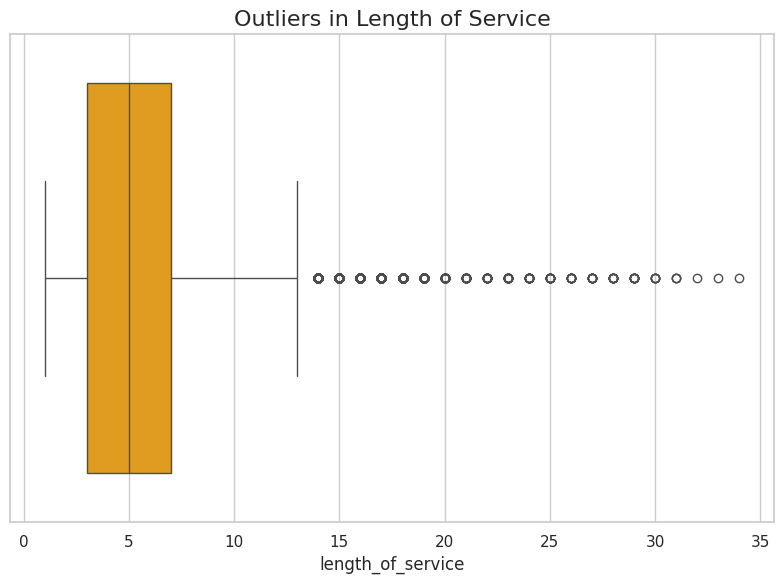

In [ ]:
# Chart 17: Length of Service Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(
    x=df['length_of_service'],
    color='orange'
)

plt.title("Outliers in Length of Service", fontsize=16)

plt.tight_layout()

plt.savefig("Outliers in Length of Service.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/1850705758.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


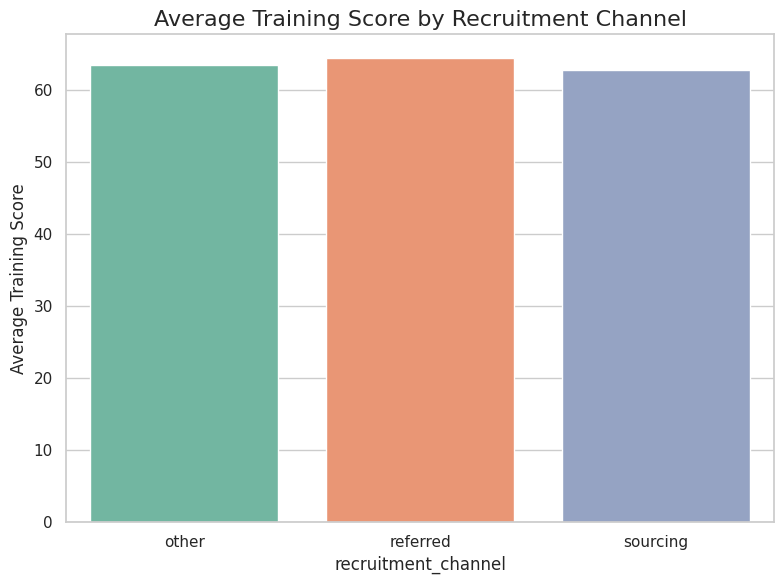

In [ ]:
# Chart 18: Average Training Score by Recruitment Channel

plt.figure(figsize=(8,6))

recruitment = df.groupby('recruitment_channel')['avg_training_score'].mean()

sns.barplot(
    x=recruitment.index,
    y=recruitment.values,
    palette='Set2'
)

plt.title("Average Training Score by Recruitment Channel", fontsize=16)

plt.ylabel("Average Training Score")

plt.tight_layout()

plt.savefig("Average Training Score by Recruitment Channel.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/4251208003.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  experience = df.groupby('Experience_Level')['avg_training_score'].mean()
/tmp/ipykernel_2694/4251208003.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


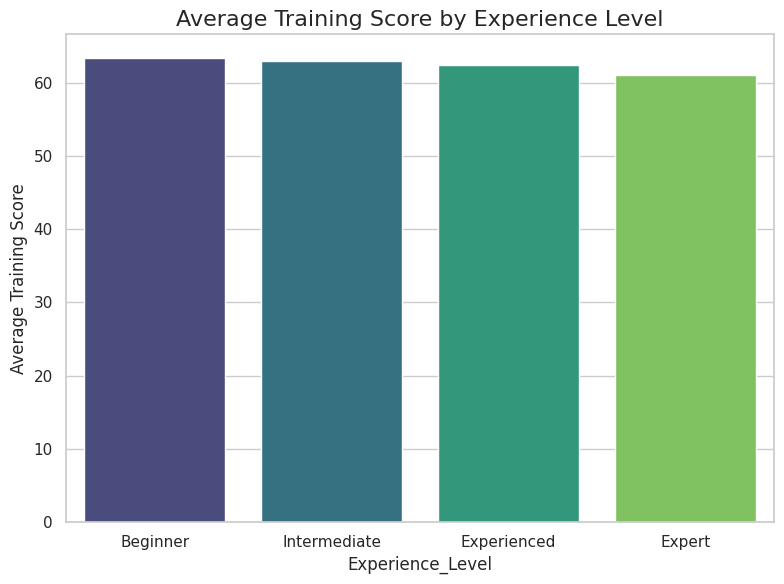

In [ ]:
# Chart 19: Average Training Score by Experience Level

plt.figure(figsize=(8,6))

experience = df.groupby('Experience_Level')['avg_training_score'].mean()

sns.barplot(
    x=experience.index,
    y=experience.values,
    palette='viridis'
)

plt.title("Average Training Score by Experience Level", fontsize=16)

plt.ylabel("Average Training Score")

plt.tight_layout()

plt.savefig("Average Training Score by Experience Level.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/47593481.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


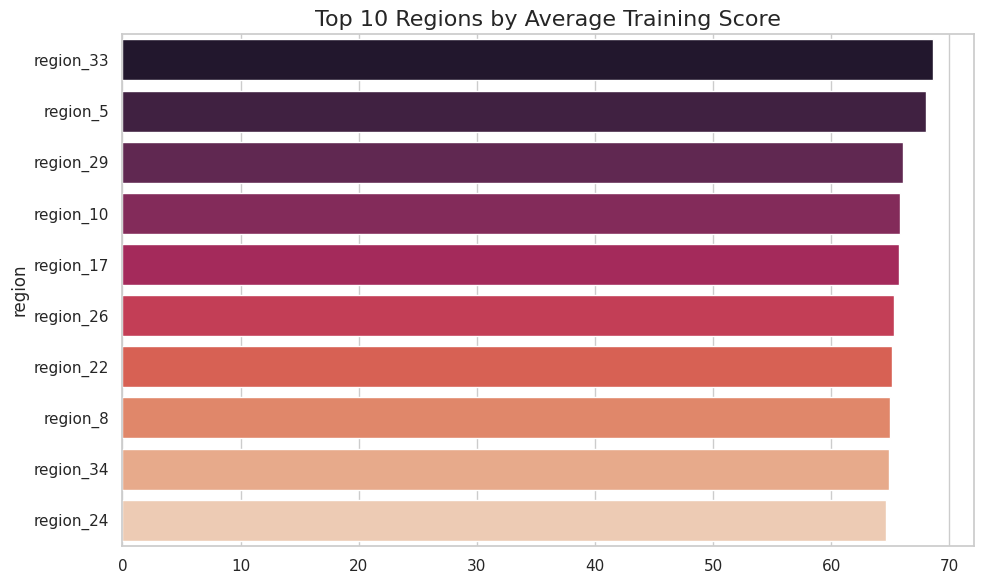

In [ ]:
# Chart 20: Top 10 Regions by Average Training Score

top_regions = (
    df.groupby('region')['avg_training_score']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_regions.values,
    y=top_regions.index,
    palette='rocket'
)

plt.title("Top 10 Regions by Average Training Score", fontsize=16)

plt.tight_layout()

plt.savefig("Top 10 Regions by Average Training Score.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/3618392313.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


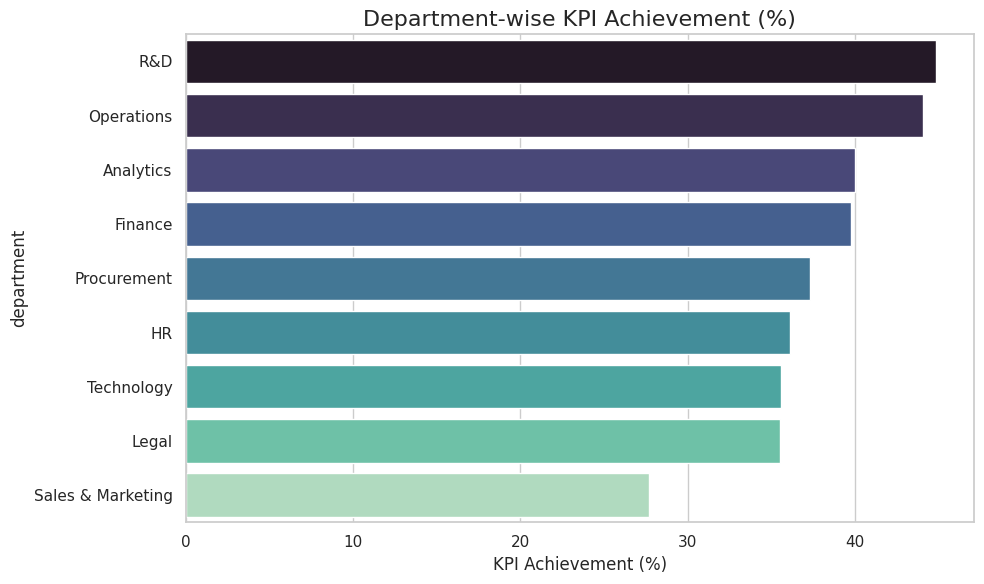

In [ ]:
# Chart 21: Department-wise KPI Achievement

kpi = (
    df.groupby('department')['KPIs_met_more_than_80']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=kpi.values * 100,
    y=kpi.index,
    palette='mako'
)

plt.title("Department-wise KPI Achievement (%)", fontsize=16)

plt.xlabel("KPI Achievement (%)")

plt.tight_layout()

plt.savefig("Department-wise KPI Achievement.png", dpi=300)

plt.show()

/tmp/ipykernel_2694/1934879700.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


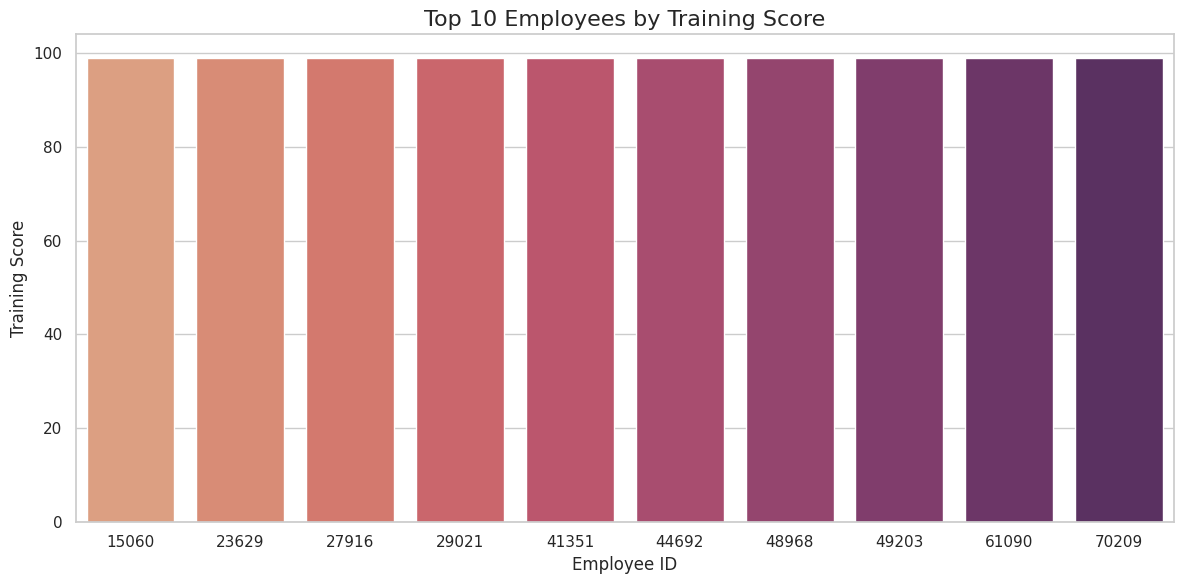

In [ ]:
# Chart 22: Top 10 Employees by Training Score

top_emp = (
    df.sort_values(by='avg_training_score', ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x='employee_id',
    y='avg_training_score',
    data=top_emp,
    palette='flare'
)

plt.title("Top 10 Employees by Training Score", fontsize=16)

plt.xlabel("Employee ID")
plt.ylabel("Training Score")

plt.tight_layout()

plt.savefig("Top 10 Employees by Training Score.png", dpi=300)

plt.show()

In [ ]:
# Total Employees

total_employees = len(df)

print("Total Employees:", total_employees)

Total Employees: 17415


In [ ]:
# Average Training Score

avg_training = round(df['avg_training_score'].mean(), 2)

print("Average Training Score:", avg_training)

Average Training Score: 63.18


In [ ]:
# Average Years of Service

avg_experience = round(df['length_of_service'].mean(), 2)

print("Average Years of Service:", avg_experience)

Average Years of Service: 5.8


In [ ]:
# Average Employee Age

avg_age = round(df['age'].mean(), 2)

print("Average Age:", avg_age)

Average Age: 34.81


In [ ]:
# KPI Achievement Percentage

kpi_rate = round(
    (df['KPIs_met_more_than_80'].sum() / total_employees) * 100,
    2
)

print("KPI Achievement Rate:", kpi_rate, "%")

KPI Achievement Rate: 35.89 %


In [ ]:
# Award Winning Percentage

award_rate = round(
    (df['awards_won'].sum() / total_employees) * 100,
    2
)

print("Award Winning Rate:", award_rate, "%")

Award Winning Rate: 2.34 %


In [ ]:
# Previous Year Rating

avg_rating = round(df['previous_year_rating'].mean(),2)

print("Average Previous Year Rating:", avg_rating)

Average Previous Year Rating: 3.35


In [ ]:
# Department with Highest Average Training Score

top_department = (
    df.groupby('department')['avg_training_score']
      .mean()
      .idxmax()
)

top_department_score = (
    df.groupby('department')['avg_training_score']
      .mean()
      .max()
)

print("Top Department:", top_department)
print("Average Training Score:", round(top_department_score,2))

Top Department: Analytics
Average Training Score: 84.57


In [ ]:
# Region with Highest Training Score

top_region = (
    df.groupby('region')['avg_training_score']
      .mean()
      .idxmax()
)

top_region_score = (
    df.groupby('region')['avg_training_score']
      .mean()
      .max()
)

print("Top Region:", top_region)
print("Average Training Score:", round(top_region_score,2))

Top Region: region_33
Average Training Score: 68.66


In [ ]:
print(top_region)
print(top_region_score)

region_33
68.65934065934066


In [ ]:
# Highest Training Score

highest_score = df['avg_training_score'].max()

print("Highest Training Score:", highest_score)

Highest Training Score: 99


In [ ]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met_more_than_80', 'awards_won',
       'avg_training_score', 'Age_Group', 'Experience_Level',
       'Training_Category', 'KPI_Status', 'Award_Status',
       'Performance_Category'],
      dtype='object')

In [ ]:
# KPI Summary Table

kpi_summary = pd.DataFrame({

    "KPI":[

        "Total Employees",
        "Average Age",
        "Average Experience",
        "Average Training Score",
        "Average Previous Year Rating",
        "KPI Achievement Rate (%)",
        "Award Winning Rate (%)",
        "Top Performing Department",
        "Top Performing Region",
        "Highest Training Score"

    ],

    "Value":[

        total_employees,
        avg_age,
        avg_experience,
        avg_training,
        avg_rating,
        kpi_rate,
        award_rate,
        top_department,
        top_region,
        highest_score

    ]

})

kpi_summary

,KPI,Value
0,Total Employees,17415
1,Average Age,34.81
2,Average Experience,5.8
3,Average Training Score,63.18
4,Average Previous Year Rating,3.35
5,KPI Achievement Rate (%),35.89
6,Award Winning Rate (%),2.34
7,Top Performing Department,Analytics
8,Top Performing Region,region_33
9,Highest Training Score,99


In [ ]:
# Save KPI Summary

kpi_summary.to_csv("Employee_Productivity_KPI_Summary.csv",index=False)

print("KPI Summary Saved Successfully!")

KPI Summary Saved Successfully!


/tmp/ipykernel_2694/853128890.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


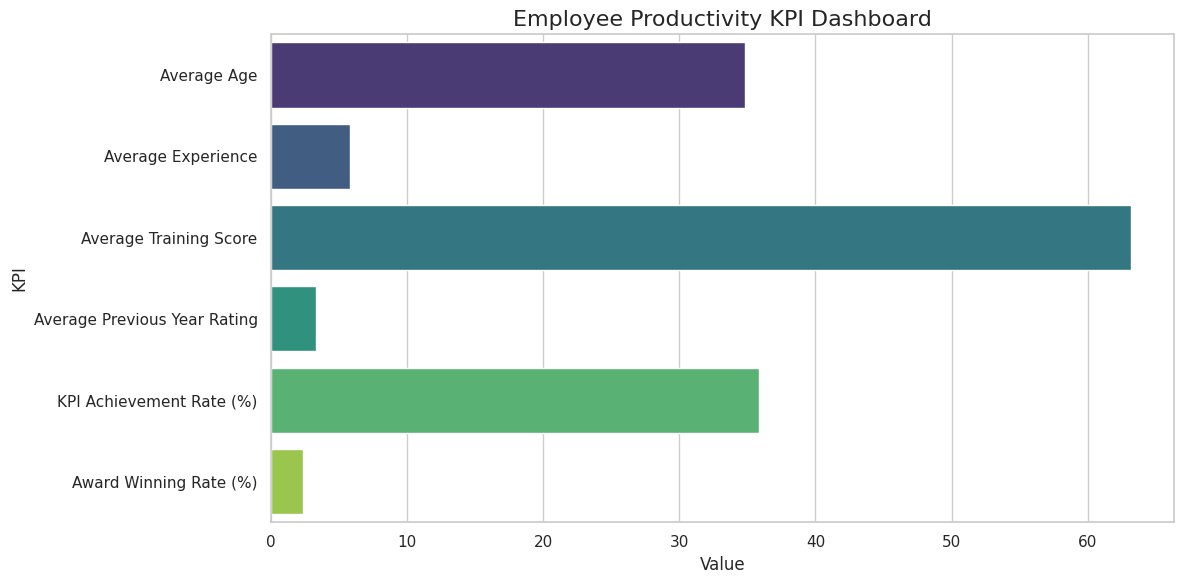

In [ ]:
# KPI Dashboard

plt.figure(figsize=(12,6))

sns.barplot(
    data=kpi_summary.iloc[1:7],
    x='Value',
    y='KPI',
    palette='viridis'
)

plt.title("Employee Productivity KPI Dashboard",fontsize=16)

plt.tight_layout()

plt.savefig("Employee Productivity KPI Dashboard.png",dpi=300)

plt.show()